# Binning 'spaxels' into annular bins and partitioning galaxy sample

This notebook demonstrates how to bin 'spaxels' into annular bins and partition a galaxy sample. The spaxel-level data is available through [this Zenodo repository](https://doi.org/10.5281/zenodo.15476126).

Note that although gas mass is included here, the analysis we perform in the rest of this repository focuses on information gleaned from stellar particles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Sorting spaxels into bins, based on subID and bin size

In [2]:
def bin_annuli(subID, binsize, exclude_end = True, exclude_loSFR = False, exclude_logas= False):
    """
    For galaxy subID, bin the spaxels into annuli of size binsize.
    Binsize is in kpc (physical units)
    But the spaxel radii are normalized by Reff (and squared).
    We want all the annular bins to be the same physical size, so we need to account for the different normalizations
    The spaxel maps have side lengths of 2*Reff

    kwargs
    ----------      
    subID: int
        The subhalo ID of the galaxy to be binned.
    binsize : float
        The size of the annular bins in kpc.
    exclude_end : bool, default is True
        If True, the last bin will be excluded 
        (i.e. the outermost annulus will not be included because it would be smaller than the others)
    exclude_loSFR: bool, default is False
        If True, spaxels with SFR estimated with lower limit will be excluded from the binning.
    exclude_logas: bool, default is False
        If True, spaxels with gas mass estimated with lower limit will be excluded from the binning.

    Returns
    ----------  
    bin_centers : array
        The centers of the annular bins in kpc. (i.e., radii of the annuli)
    bin_s_mass : array
        The average stellar mass surface density in each bin, in log10(M_sun/kpc^2).
    bin_sfr : array
        The average star formation rate surface density in each bin, in log10(M_sun/yr/kpc^2).
    bin_gas_mass : array    
        The average gas mass surface density in each bin, in log10(M_sun/kpc^2).
    bin_filling : array 
        If exclude_loSFR is True, the ratio of total spaxel coverage to full area of the annulus.
        Else, the ratio of spaxels with 'good' SFR (indicator !=0) to the total number of spaxels in the annulus.
        Should not be included in feature analysis, but can be used internally to determine how a binning scheme is working.
        Generally, higher filling factors are preferred.
    """
    h=0.6774 # Planck 2015 cosmology, h = H0/100
    # Load the spaxel data for the specified subID
    # Data is in log space, but the calculation for combining them needs them in linear space
    # Generally preferable to avoid doing powers when possible for compuatational efficiency but alas

    #check if file exists (this will exclude galaxies with N_stars<1000)
    try: spax_dat = np.load(f'flattened/spaxel_list_{subID}.npy')
    except FileNotFoundError: return None, None, None, None, None
    s_mass = 10**spax_dat[:,0]
    sfr = 10**spax_dat[:,1]
    rsq = spax_dat[:,2]
    sfr_indicator = spax_dat[:,3]
    gas_mass = 10**spax_dat[:,4]
    gas_indicator = spax_dat[:,5]

    # Remove spaxels where data was estimated for low levels of gas and/or star formation
    if exclude_loSFR and exclude_logas: wh_ex = np.nonzero((sfr_indicator!=0) & (gas_indicator!=0))
    elif exclude_loSFR: wh_ex = np.nonzero((sfr_indicator!=0))
    elif exclude_logas: wh_ex = np.nonzero((gas_indicator!=0))

    if exclude_loSFR or exclude_logas:
        s_mass = s_mass[wh_ex]
        sfr = sfr[wh_ex]
        rsq = rsq[wh_ex]
        gas_mass = gas_mass[wh_ex]
    

    # Load the subhalo catalog to get Reff
    subhalo_cat = np.load('subhalocat.npy',allow_pickle=True).item()
    IDs = subhalo_cat['subID'].astype(int)
    all_rads = subhalo_cat['Reff']/h # convert units to physical kpc
    Reff = all_rads[IDs == subID][0] # get the Reff for this subID
    #print(Reff)

    #Define binsize in normalized units and create evenly spaced bins
    binscale = binsize / Reff
    bins = np.arange(0, 2.0, binscale) # 0 to 2 Reff in normalized units

    if not exclude_end:
        bins = np.append(bins, 2.0) # add the outer edge of the last bin

    #square the bin edges for compatability with spaxel data
    #(squaring is computationally faster than taking the square root)
    bins_sq = np.square(bins)
    
    #Define bin centers
    bin_centers = (bins[:-1] + bins[1:]) / 2.0 # average of the edges

    #Sort spaxels into bins
    bin_sort = np.digitize(rsq, bins_sq) # bin_sort is the index of the bin each spaxel belongs to

    #Create arrays to store binned data
    bin_sfr = np.zeros(len(bin_centers))
    bin_s_mass = np.zeros(len(bin_centers))
    bin_gas_mass = np.zeros(len(bin_centers))
    bin_filling = np.zeros(len(bin_centers))
    #Loop over the bins and calculate the values of the properties in each bin
    for i in range(len(bin_centers)):
        #Get the indices of the spaxels in this bin
        bin_indices = np.nonzero((bin_sort == i+1))  # +1 because bin_sort is 1-indexed
        N_spax = len(bin_indices[0]) # number of spaxels in this bin
        if N_spax == 0:
            continue
        #Calculate surface densities of the properties in this bin
        #Transform back to log space
        bin_s_mass[i] = np.log10( np.sum(s_mass[bin_indices]) / N_spax )
        bin_sfr[i] = np.log10( np.sum(sfr[bin_indices]) / N_spax )
        bin_gas_mass[i] = np.log10( np.sum(gas_mass[bin_indices]) / N_spax )

        
        if exclude_loSFR:
            #compute ratio of total spaxel coverage to full area of the annulus
            bin_area = np.pi * (bins_sq[i+1] - bins_sq[i]) * Reff**2 # area of the bin in kpc^2
            spax_area = N_spax*(0.5/h)**2 # area of the spaxel in kpc^2
            #print(spax_area)
            bin_filling[i] = spax_area / bin_area
        else:
            #compute ratio of SF spaxels to total spaxels in the bin
            bin_sfr_indicator = sfr_indicator[bin_indices]
            bin_filling[i] = len(bin_sfr_indicator[bin_sfr_indicator !=0]) / N_spax
    
    return(bin_centers, bin_s_mass, bin_sfr, bin_gas_mass, bin_filling)


### Looping over all galaxies in subhalocat

In [3]:
binsize = 1.5 #kpc
#Reasonable bin sizes probably range from ~0.75 to 2.5 kpc. 
#The smallest galaxies have radii of only 4 kpc (and data that extends to 8 kpc). So even 2.5 is extreme.
#Individual spaxels have side length of ~0.75 kpc, so 1.5 kpc is about two spaxels
subhalo_cat = np.load('subhalocat.npy', allow_pickle=True).item()
IDs = subhalo_cat['subID']

r = np.asarray([])
s_mass = np.asarray([])
sfr = np.asarray([])
gas_mass = np.asarray([])
filling = np.asarray([])
allIDs = np.asarray([])
for i in IDs:
    # exclude_loSFR = false for classification
    bin_centers, bin_s_mass, bin_sfr, bin_gas_mass, bin_filling = bin_annuli(i, binsize)
    if bin_centers is None: continue
    r = np.concatenate((r, bin_centers))
    s_mass = np.concatenate((s_mass, bin_s_mass))
    sfr = np.concatenate((sfr, bin_sfr))
    gas_mass = np.concatenate((gas_mass, bin_gas_mass))
    filling = np.concatenate((filling, bin_filling))
    allIDs = np.concatenate((allIDs, i*np.ones(len(bin_centers))))

  

### Identifying scaling relation for star-forming threshold

In [4]:
from ScaleRPy.man_dat import SpatGalDat

In [5]:
# exclude_loSFR = True ONLY for finding slope/intercept
#build dataset excluding the SFRs with estimated lower limits

r_SFR_true = np.asarray([])
s_mass_SFR_true = np.asarray([])
sfr_SFR_true = np.asarray([])
gas_mass_SFR_true = np.asarray([])

for i in IDs:
    # excludes spaxels with SFR indicator = 0 (this is an artificially imposed minimum)
    bin_centers_true, bin_s_mass_true, bin_sfr_true, bin_gas_mass_true, bin_filling_true = bin_annuli(i, binsize, exclude_loSFR=True)
    if bin_centers_true is None: continue
    r_SFR_true = np.concatenate((r_SFR_true, bin_centers_true)) #bin radii
    s_mass_SFR_true = np.concatenate((s_mass_SFR_true, bin_s_mass_true)) # average stellar mass surface density
    sfr_SFR_true = np.concatenate((sfr_SFR_true, bin_sfr_true)) # average star formation rate
    gas_mass_SFR_true = np.concatenate((gas_mass_SFR_true, bin_gas_mass_true)) # average gas mass



rSFMS slope:  0.7925210196885569 +\- 0.01875618434232747
rSFMS intercept:  -7.571978869402589 +\- 0.1414249345201885


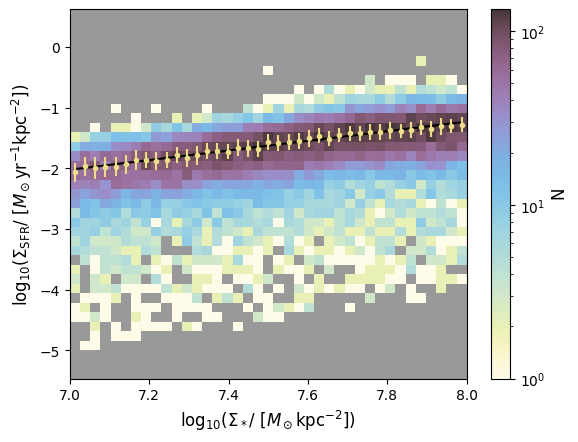

In [6]:
#Create a SpatGalDat object to hold the data
dat = SpatGalDat(s_mass = s_mass_SFR_true, sfr= sfr_SFR_true, scale='log')
#Note that we are not fitting over the full range of data
#This relatively narrow range should encompass the linear regime of the SFMS for any reasonable binning schema
out = dat.SFMS_ridge(xrange=(7,8), fittype='kde', linefit='single', contouring=False)#, numxbins=20, numybins=20)
print('rSFMS slope: ', dat.SFMS_params[0], '+\\-', dat.SFMS_paramerr[0])
print('rSFMS intercept: ', dat.SFMS_params[1], '+\\-', dat.SFMS_paramerr[1])

In [7]:
# check that the lengths of arrays are equal first
if len(s_mass) == len(sfr):
    print(len(s_mass))

63104


In [8]:
quenched_spaxels = []
star_forming_spaxels = []
quenching_number_data = []
quenching_vector = []
delta_sum_SFRs = []
log10_rSFR_MS_values = []
count = 0

rSFMS_slope = dat.SFMS_params[0]
rSFMS_intercept = dat.SFMS_params[1]

for i in range(len(sfr)):
    count = count + 1
    
    
    # calculate log10(rSFR,MS) using log10(rMass) and new slope/intercept
    log10_rSFR_MS = rSFMS_slope * s_mass[i] + rSFMS_intercept
    
    # calculate ΔΣSFR
    delta_sum_SFR = sfr[i] - log10_rSFR_MS
    
        # Bluck’s: delta_SFR >-0.6 for star-forming and delta_SFR <-1.1 for quenched
    # if ΔΣSFR < -2.4 : Quenched spaxels 
    if delta_sum_SFR < -2.4:
        quenched_spaxels.append([i, 1])
        quenching_vector.append(1)  
    else:
        star_forming_spaxels.append([i, 0])
        quenching_vector.append(0)
    delta_sum_SFRs.append(delta_sum_SFR)
    log10_rSFR_MS_values.append(log10_rSFR_MS)
    quenching_number_data.append([i, quenching_vector])

print(count)                    
print('Quenched spaxel count: ', len(quenched_spaxels))
print('Star forming spaxel count', len(star_forming_spaxels))
    
    

63104
Quenched spaxel count:  21983
Star forming spaxel count 41121


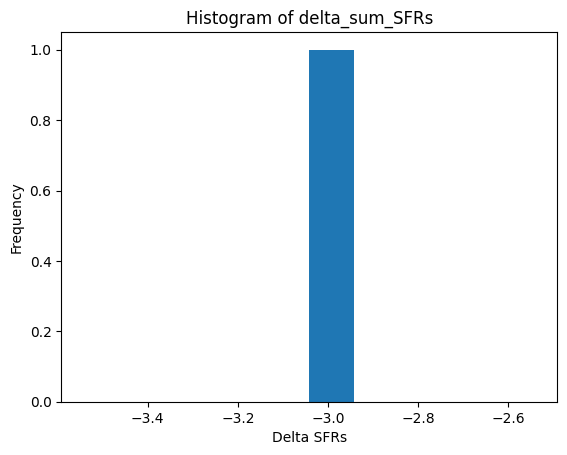

In [9]:
delta_sum_SFRs = np.array(delta_sum_SFRs, dtype=object)
import matplotlib.pyplot as plt

plt.hist(delta_sum_SFR, bins=10)  # You can adjust the number of bins
plt.xlabel("Delta SFRs")
plt.ylabel("Frequency")
plt.title("Histogram of delta_sum_SFRs")
plt.show()

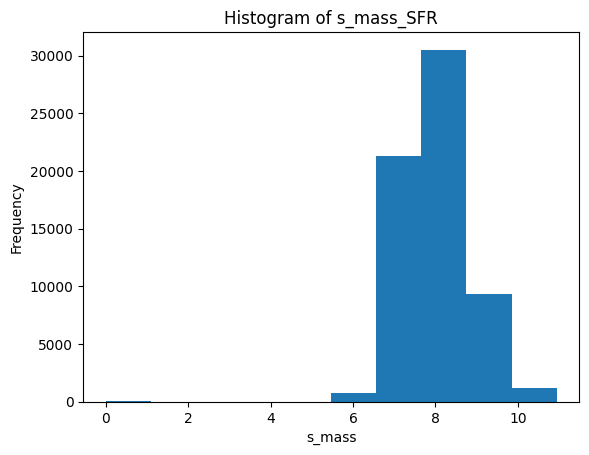

In [10]:
import matplotlib.pyplot as plt

plt.hist(s_mass, bins=10)  # You can adjust the number of bins
plt.xlabel("s_mass")
plt.ylabel("Frequency")
plt.title("Histogram of s_mass_SFR")
plt.show()

In [11]:
quenching_vector = np.array(quenching_vector, dtype=object)

annuli_df = pd.DataFrame({
    'subID': allIDs,
    'bin_radii': r,
    'avg_s_mass': s_mass,
    'avg_SFR': sfr,
    'avg_gas_mass': gas_mass,
    'quenching_vector': quenching_vector
})
annuli_df = annuli_df[annuli_df['avg_s_mass'] != 0]
annuli_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector
0,0.0,0.010883,10.939674,-1.120602,7.966769,0
1,0.0,0.032649,10.494615,-1.556470,7.919378,0
2,0.0,0.054415,9.982732,-2.017950,7.934402,0
3,0.0,0.076182,9.739688,-2.263846,7.927703,1
4,0.0,0.097948,9.594884,-2.389380,7.926022,1
...,...,...,...,...,...,...
63099,755674.0,0.445985,7.800349,-4.208787,4.745439,1
63100,755674.0,0.743309,7.416642,-4.607568,4.934123,1
63101,755674.0,1.040633,7.098891,-4.875287,4.386663,1
63102,755674.0,1.337956,6.887413,-5.109916,4.235222,1


In [12]:
import pandas as pd

subhalo_gas_mass= pd.read_parquet('subhalo_gas_mass.parquet')
subhalo_gas_mass = subhalo_gas_mass.rename(columns={'0': 'gas_mass'})
subhalo_gas_mass = subhalo_gas_mass[['subID', 'gas_mass']]
subhalo_gas_mass
# print(df.head())
# non_zero_rows_count = (subhalo_gas_mass != 0).any(axis=1).sum()

# print("Number of rows with at least one non-zero value:", non_zero_rows_count)

,subID,gas_mass
0,0,19187.548828
1,1,5069.831055
2,2,0.000000
3,3,0.000000
4,4,0.000000
...,...,...
14485704,14485704,0.000000
14485705,14485705,0.000000
14485706,14485706,0.000000
14485707,14485707,0.000000


### Combining Annuli Bins with Global Variables

In [13]:
n_stars_data = np.loadtxt('N_stars.txt')
n_stars_filtered_indices = np.where(n_stars_data > 1000)[0]
# converting np array into dict
subhalocat_data = np.load('subhalocat.npy', allow_pickle=True).item()
subID_array = subhalocat_data['subID']

subID_list = []

# getting the subids for the specific n_star filtered indices
for idx in n_stars_filtered_indices:
    subID_list.append(subID_array[idx])

In [14]:
global_SFRs = np.load('glSFRs_all.npy')

columns_to_merge = ["subID", "s_mass", "BHMass", "class", "veldisp"]

subhalocat_df_global = pd.DataFrame({col: subhalocat_data[col] for col in columns_to_merge})

# add the global_SFRs as a new column
subhalocat_df_global['global_SFRs'] = global_SFRs
subhalocat_df_global

,subID,s_mass,BHMass,class,veldisp,global_SFRs
0,0,251.016312,0.700941,0.0,603.875061,0.456323
1,1,37.852551,0.125518,1.0,333.893250,0.197048
2,2,42.482437,0.177487,1.0,297.577271,10.190812
3,3,11.620896,0.034418,1.0,159.561844,4.710709
4,4,9.032478,0.052240,1.0,168.744232,0.812597
...,...,...,...,...,...,...
7158,801859,0.044760,0.000000,0.0,27.550901,0.000578
7159,802484,0.029280,0.000000,0.0,36.776436,0.000475
7160,802884,0.027975,0.000000,0.0,34.439064,0.000419
7161,831034,0.047586,0.000000,0.0,31.719425,0.000886


In [15]:
subhalocat_df_global_new = pd.merge(subhalo_gas_mass, subhalocat_df_global, on='subID', how='inner')
subhalocat_df_global_new

,subID,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs
0,0,19187.548828,251.016312,0.700941,0.0,603.875061,0.456323
1,1,5069.831055,37.852551,0.125518,1.0,333.893250,0.197048
2,2,0.000000,42.482437,0.177487,1.0,297.577271,10.190812
3,3,0.000000,11.620896,0.034418,1.0,159.561844,4.710709
4,4,0.000000,9.032478,0.052240,1.0,168.744232,0.812597
...,...,...,...,...,...,...,...
7158,801859,0.000000,0.044760,0.000000,0.0,27.550901,0.000578
7159,802484,0.000000,0.029280,0.000000,0.0,36.776436,0.000475
7160,802884,0.023036,0.027975,0.000000,0.0,34.439064,0.000419
7161,831034,0.000000,0.047586,0.000000,0.0,31.719425,0.000886


In [16]:
# merging subhalo and auxcat data
auxcat_data = np.load('auxcat.npy', allow_pickle=True).item()

columns_to_merge = ["BH_cumQM", "BH_cumRM", "Mhalo", "overdens", "bulge", "Bfld"]

# converting the selected columns to a DataFrame
auxcat_data_df = pd.DataFrame({key: auxcat_data[key] for key in columns_to_merge})

subhalo_auxcat_df = pd.concat([subhalocat_df_global_new.reset_index(drop=True), auxcat_data_df.reset_index(drop=True)], axis=1)
subhalo_auxcat_df


,subID,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld
0,0,19187.548828,251.016312,0.700941,0.0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462
1,1,5069.831055,37.852551,0.125518,1.0,333.893250,0.197048,97180768.0,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681
2,2,0.000000,42.482437,0.177487,1.0,297.577271,10.190812,108924800.0,1.388802e-316,38878.035156,5703.983062,0.671275,1.775232
3,3,0.000000,11.620896,0.034418,1.0,159.561844,4.710709,10704808.0,1.388802e-316,38878.035156,94.438007,0.206207,0.122587
4,4,0.000000,9.032478,0.052240,1.0,168.744232,0.812597,16131864.0,3.538992e-320,38878.035156,102.843703,0.963294,0.199844
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,801859,0.000000,0.044760,0.000000,0.0,27.550901,0.000578,NaN,NaN,1.537664,17.616758,NaN,0.081800
7159,802484,0.000000,0.029280,0.000000,0.0,36.776436,0.000475,NaN,NaN,1.957088,12.457016,NaN,NaN
7160,802884,0.023036,0.027975,0.000000,0.0,34.439064,0.000419,NaN,NaN,1.943503,17.321979,NaN,NaN
7161,831034,0.000000,0.047586,0.000000,0.0,31.719425,0.000886,NaN,NaN,1.324914,15.307291,NaN,NaN


In [17]:
df_merged = pd.merge(annuli_df, subhalo_auxcat_df, on='subID', how='inner')
df_merged['class'] = df_merged['class'].astype(int)

h = 0.6774
df_merged['s_mass'] = df_merged['s_mass'] / h

df_merged
class_counts = df_merged["class"].value_counts()
print(class_counts)

class
0    48576
1    14506
Name: count, dtype: int64


In [18]:
df_merged['BH_AGN'] = df_merged['BH_cumQM'] + df_merged['BH_cumRM'] 
df_merged

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,0.0,0.010883,10.939674,-1.120602,7.966769,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
1,0.0,0.032649,10.494615,-1.556470,7.919378,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
2,0.0,0.054415,9.982732,-2.017950,7.934402,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
3,0.0,0.076182,9.739688,-2.263846,7.927703,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
4,0.0,0.097948,9.594884,-2.389380,7.926022,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,NaN,NaN,2.820780,32.637203,NaN,NaN,NaN
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,NaN,NaN,2.820780,32.637203,NaN,NaN,NaN
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,NaN,NaN,2.820780,32.637203,NaN,NaN,NaN
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,NaN,NaN,2.820780,32.637203,NaN,NaN,NaN


In [19]:
# drop rows where the 'BH_mass' column has NaN values
df_merged = df_merged.dropna(subset=["BHMass"])
df_merged

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,0.0,0.010883,10.939674,-1.120602,7.966769,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
1,0.0,0.032649,10.494615,-1.556470,7.919378,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
2,0.0,0.054415,9.982732,-2.017950,7.934402,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
3,0.0,0.076182,9.739688,-2.263846,7.927703,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
4,0.0,0.097948,9.594884,-2.389380,7.926022,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,NaN,NaN,2.820780,32.637203,NaN,NaN,NaN
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,NaN,NaN,2.820780,32.637203,NaN,NaN,NaN
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,NaN,NaN,2.820780,32.637203,NaN,NaN,NaN
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,NaN,NaN,2.820780,32.637203,NaN,NaN,NaN


In [20]:
    # NaN values for BH_cumQM should be replaced with zeros
df_merged["BH_cumQM"] = df_merged["BH_cumQM"].fillna(0)
df_merged["BH_cumRM"] = df_merged["BH_cumRM"].fillna(0)
df_merged["BH_AGN"] = df_merged["BH_AGN"].fillna(0)
df_merged["Bfld"] = df_merged["Bfld"].fillna(0)
# checking if there are any remaining NaN value in the low mass satellite df
has_nan = df_merged.isna().any().any()  # Returns True if any NaN exists, False otherwise
print(has_nan)

True


In [21]:
df_merged = df_merged[df_merged['avg_s_mass'] != 0]

In [22]:
df_merged

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,0.0,0.010883,10.939674,-1.120602,7.966769,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
1,0.0,0.032649,10.494615,-1.556470,7.919378,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
2,0.0,0.054415,9.982732,-2.017950,7.934402,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
3,0.0,0.076182,9.739688,-2.263846,7.927703,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
4,0.0,0.097948,9.594884,-2.389380,7.926022,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0


In [23]:
df_merged[df_merged['quenching_vector'] == 0]

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,0.0,0.010883,10.939674,-1.120602,7.966769,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
1,0.0,0.032649,10.494615,-1.556470,7.919378,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
2,0.0,0.054415,9.982732,-2.017950,7.934402,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
91,1.0,0.037018,10.065946,-1.977420,6.628361,0,5069.831055,55.879173,0.125518,1,333.893250,0.197048,97180768.0,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,97180768.0
92,1.0,0.111053,9.816378,-2.138036,6.690369,0,5069.831055,55.879173,0.125518,1,333.893250,0.197048,97180768.0,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,97180768.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63036,702046.0,0.178702,8.114720,-1.296303,7.687575,0,0.000000,0.142014,0.000000,0,48.393726,0.277645,0.0,0.000000e+00,4.553244,-0.161578,NaN,0.121859,0.0
63037,702046.0,0.536105,8.014228,-1.850880,7.689039,0,0.000000,0.142014,0.000000,0,48.393726,0.277645,0.0,0.000000e+00,4.553244,-0.161578,NaN,0.121859,0.0
63038,702046.0,0.893508,7.557265,-1.612207,7.680125,0,0.000000,0.142014,0.000000,0,48.393726,0.277645,0.0,0.000000e+00,4.553244,-0.161578,NaN,0.121859,0.0
63039,702046.0,1.250912,7.199104,-2.294763,7.566593,0,0.000000,0.142014,0.000000,0,48.393726,0.277645,0.0,0.000000e+00,4.553244,-0.161578,NaN,0.121859,0.0


In [24]:
df_merged[df_merged['quenching_vector'] == 1]

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
3,0.0,0.076182,9.739688,-2.263846,7.927703,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
4,0.0,0.097948,9.594884,-2.389380,7.926022,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
5,0.0,0.119714,9.494704,-2.496717,7.905093,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
6,0.0,0.141480,9.419095,-2.575948,7.936082,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
7,0.0,0.163246,9.354842,-2.628639,7.913407,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0


### Splitting into low-/high- centrals/satellite dfs

In [25]:
df_merged[df_merged["class"] == 0]

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,0.0,0.010883,10.939674,-1.120602,7.966769,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
1,0.0,0.032649,10.494615,-1.556470,7.919378,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
2,0.0,0.054415,9.982732,-2.017950,7.934402,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
3,0.0,0.076182,9.739688,-2.263846,7.927703,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
4,0.0,0.097948,9.594884,-2.389380,7.926022,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,567822848.0,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,567822848.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.0,0.000000e+00,2.820780,32.637203,NaN,0.000000,0.0


In [26]:
df_merged[df_merged["class"] == 1]

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
91,1.0,0.037018,10.065946,-1.977420,6.628361,0,5069.831055,55.879173,0.125518,1,333.893250,0.197048,97180768.0,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
92,1.0,0.111053,9.816378,-2.138036,6.690369,0,5069.831055,55.879173,0.125518,1,333.893250,0.197048,97180768.0,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
93,1.0,0.185088,9.498950,-2.488943,6.717174,1,5069.831055,55.879173,0.125518,1,333.893250,0.197048,97180768.0,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
94,1.0,0.259123,9.273945,-2.704103,6.806918,1,5069.831055,55.879173,0.125518,1,333.893250,0.197048,97180768.0,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
95,1.0,0.333158,9.124043,-2.386751,7.096273,0,5069.831055,55.879173,0.125518,1,333.893250,0.197048,97180768.0,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54860,593573.0,0.461125,7.915781,-3.874264,7.566107,1,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.0,1.027657e-321,21.333946,3.807714,NaN,0.168837,1.027657e-321
54861,593573.0,0.768541,7.496673,-2.880743,7.366165,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.0,1.027657e-321,21.333946,3.807714,NaN,0.168837,1.027657e-321
54862,593573.0,1.075957,7.168706,-3.435107,7.380437,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.0,1.027657e-321,21.333946,3.807714,NaN,0.168837,1.027657e-321
54863,593573.0,1.383374,6.925375,-3.566125,7.352052,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.0,1.027657e-321,21.333946,3.807714,NaN,0.168837,1.027657e-321


In [27]:
df_merged[df_merged["s_mass"] > 2.0]

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,0.0,0.010883,10.939674,-1.120602,7.966769,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
1,0.0,0.032649,10.494615,-1.556470,7.919378,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
2,0.0,0.054415,9.982732,-2.017950,7.934402,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
3,0.0,0.076182,9.739688,-2.263846,7.927703,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
4,0.0,0.097948,9.594884,-2.389380,7.926022,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54984,594444.0,0.169860,9.321200,-2.636930,6.265163,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54985,594444.0,0.509579,8.999712,-1.776677,6.709038,0,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54986,594444.0,0.849298,8.734355,-3.316755,7.059817,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54987,594444.0,1.189017,8.498129,-3.504491,6.857232,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04


In [28]:
df_merged[df_merged["s_mass"] <= 2.0]

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
439,37.0,0.174505,8.905776,-0.052619,8.682093,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.0,38878.035156,202.795135,-0.682291,0.694089,8761.889648
440,37.0,0.523516,8.636583,-0.643683,8.302815,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.0,38878.035156,202.795135,-0.682291,0.694089,8761.889648
441,37.0,0.872526,8.421218,-1.414926,7.867777,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.0,38878.035156,202.795135,-0.682291,0.694089,8761.889648
442,37.0,1.221537,8.243556,-1.699316,7.714798,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.0,38878.035156,202.795135,-0.682291,0.694089,8761.889648
443,37.0,1.570547,8.094305,-1.657207,7.711024,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.0,38878.035156,202.795135,-0.682291,0.694089,8761.889648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.000000,0.0,2.820780,32.637203,NaN,0.000000,0.000000
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.000000,0.0,2.820780,32.637203,NaN,0.000000,0.000000
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.000000,0.0,2.820780,32.637203,NaN,0.000000,0.000000
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.000000,0.155144,0.000000,0,40.501854,0.001908,0.000000,0.0,2.820780,32.637203,NaN,0.000000,0.000000


In [29]:
# class: (int) 0 if the galaxy is a central or 1 if the galaxy is a satellite
central_df = df_merged[df_merged["class"] == 0]
satellite_df = df_merged[df_merged["class"] == 1]

In [30]:
## CENTRAL GALAXIES
high_mass_central_df = central_df[central_df["s_mass"] > 2.0]
print(high_mass_central_df.shape[0])
low_mass_central_df = central_df[central_df["s_mass"] <= 2.0]
print(low_mass_central_df.shape[0])

26899
21677


In [31]:
## SATELLITE GALAXIES
high_mass_satellite_df = satellite_df[satellite_df["s_mass"] > 2.0]
print(high_mass_satellite_df.shape[0])
low_mass_satellite_df = satellite_df[satellite_df["s_mass"] <= 2.0]
print(low_mass_satellite_df.shape[0])

8675
5831


### Saving Low Mass Satellites

In [32]:
low_mass_satellite_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
439,37.0,0.174505,8.905776,-0.052619,8.682093,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
440,37.0,0.523516,8.636583,-0.643683,8.302815,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
441,37.0,0.872526,8.421218,-1.414926,7.867777,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
442,37.0,1.221537,8.243556,-1.699316,7.714798,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
443,37.0,1.570547,8.094305,-1.657207,7.711024,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54860,593573.0,0.461125,7.915781,-3.874264,7.566107,1,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,NaN,0.168837,1.027657e-321
54861,593573.0,0.768541,7.496673,-2.880743,7.366165,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,NaN,0.168837,1.027657e-321
54862,593573.0,1.075957,7.168706,-3.435107,7.380437,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,NaN,0.168837,1.027657e-321
54863,593573.0,1.383374,6.925375,-3.566125,7.352052,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,NaN,0.168837,1.027657e-321


In [33]:
# any low-mass satellite galaxies with NaN for the bulge parameter should have their bulge 
# parameter set to the median of the bulge parameter for all low-mass satellite galaxies.

median_value_low_sat = low_mass_satellite_df["bulge"].median()
low_mass_satellite_df = low_mass_satellite_df.copy()
low_mass_satellite_df["bulge"] = low_mass_satellite_df["bulge"].fillna(median_value_low_sat)
low_mass_satellite_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
439,37.0,0.174505,8.905776,-0.052619,8.682093,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
440,37.0,0.523516,8.636583,-0.643683,8.302815,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
441,37.0,0.872526,8.421218,-1.414926,7.867777,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
442,37.0,1.221537,8.243556,-1.699316,7.714798,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
443,37.0,1.570547,8.094305,-1.657207,7.711024,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54860,593573.0,0.461125,7.915781,-3.874264,7.566107,1,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54861,593573.0,0.768541,7.496673,-2.880743,7.366165,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54862,593573.0,1.075957,7.168706,-3.435107,7.380437,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54863,593573.0,1.383374,6.925375,-3.566125,7.352052,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321


In [34]:
print(low_mass_satellite_df[low_mass_satellite_df.isna().any(axis=1)])

Empty DataFrame
Columns: [subID, bin_radii, avg_s_mass, avg_SFR, avg_gas_mass, quenching_vector, gas_mass, s_mass, BHMass, class, veldisp, global_SFRs, BH_cumQM, BH_cumRM, Mhalo, overdens, bulge, Bfld, BH_AGN]
Index: []


In [35]:
# checking if there are any remaining NaN value in the low mass satellite df
has_nan = low_mass_satellite_df.isna().any().any()  # Returns True if any NaN exists, False otherwise
print(has_nan)

False


In [36]:
# saving to parquet to handle large data size
low_mass_satellite_df.to_parquet("low_mass_satellite_df_annuli_revised.parquet", engine="pyarrow")

### Saving High Mass Satellites

In [37]:
high_mass_satellite_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
91,1.0,0.037018,10.065946,-1.977420,6.628361,0,5069.831055,55.879173,0.125518,1,333.89325,0.197048,9.718077e+07,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
92,1.0,0.111053,9.816378,-2.138036,6.690369,0,5069.831055,55.879173,0.125518,1,333.89325,0.197048,9.718077e+07,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
93,1.0,0.185088,9.498950,-2.488943,6.717174,1,5069.831055,55.879173,0.125518,1,333.89325,0.197048,9.718077e+07,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
94,1.0,0.259123,9.273945,-2.704103,6.806918,1,5069.831055,55.879173,0.125518,1,333.89325,0.197048,9.718077e+07,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
95,1.0,0.333158,9.124043,-2.386751,7.096273,0,5069.831055,55.879173,0.125518,1,333.89325,0.197048,9.718077e+07,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33561,476528.0,0.179965,9.485483,-2.459436,7.232764,1,0.000000,3.387989,0.010589,1,112.13295,0.018142,1.015537e+06,0.000000e+00,121.820320,6.780018,0.403195,0.133146,1.015537e+06
33562,476528.0,0.539895,9.195900,-2.790333,6.889097,1,0.000000,3.387989,0.010589,1,112.13295,0.018142,1.015537e+06,0.000000e+00,121.820320,6.780018,0.403195,0.133146,1.015537e+06
33563,476528.0,0.899825,8.818249,-3.192451,6.611662,1,0.000000,3.387989,0.010589,1,112.13295,0.018142,1.015537e+06,0.000000e+00,121.820320,6.780018,0.403195,0.133146,1.015537e+06
33564,476528.0,1.259755,8.497334,-3.498477,6.271559,1,0.000000,3.387989,0.010589,1,112.13295,0.018142,1.015537e+06,0.000000e+00,121.820320,6.780018,0.403195,0.133146,1.015537e+06


In [38]:
# any high-mass satellite galaxies with NaN for the bulge parameter should have their bulge 
# parameter set to the median of the bulge parameter for all high-mass satellite galaxies.

median_value_high_sat = high_mass_satellite_df["bulge"].median()
high_mass_satellite_df = high_mass_satellite_df.copy()
high_mass_satellite_df["bulge"] = high_mass_satellite_df["bulge"].fillna(median_value_high_sat)

In [39]:
high_mass_satellite_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
91,1.0,0.037018,10.065946,-1.977420,6.628361,0,5069.831055,55.879173,0.125518,1,333.89325,0.197048,9.718077e+07,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
92,1.0,0.111053,9.816378,-2.138036,6.690369,0,5069.831055,55.879173,0.125518,1,333.89325,0.197048,9.718077e+07,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
93,1.0,0.185088,9.498950,-2.488943,6.717174,1,5069.831055,55.879173,0.125518,1,333.89325,0.197048,9.718077e+07,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
94,1.0,0.259123,9.273945,-2.704103,6.806918,1,5069.831055,55.879173,0.125518,1,333.89325,0.197048,9.718077e+07,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
95,1.0,0.333158,9.124043,-2.386751,7.096273,0,5069.831055,55.879173,0.125518,1,333.89325,0.197048,9.718077e+07,6.904271e-310,38878.035156,8780.408392,0.508532,0.152681,9.718077e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33561,476528.0,0.179965,9.485483,-2.459436,7.232764,1,0.000000,3.387989,0.010589,1,112.13295,0.018142,1.015537e+06,0.000000e+00,121.820320,6.780018,0.403195,0.133146,1.015537e+06
33562,476528.0,0.539895,9.195900,-2.790333,6.889097,1,0.000000,3.387989,0.010589,1,112.13295,0.018142,1.015537e+06,0.000000e+00,121.820320,6.780018,0.403195,0.133146,1.015537e+06
33563,476528.0,0.899825,8.818249,-3.192451,6.611662,1,0.000000,3.387989,0.010589,1,112.13295,0.018142,1.015537e+06,0.000000e+00,121.820320,6.780018,0.403195,0.133146,1.015537e+06
33564,476528.0,1.259755,8.497334,-3.498477,6.271559,1,0.000000,3.387989,0.010589,1,112.13295,0.018142,1.015537e+06,0.000000e+00,121.820320,6.780018,0.403195,0.133146,1.015537e+06


In [40]:
# checking if there are any remaining NaN value in the low mass satellite df
has_nan = high_mass_satellite_df.isna().any().any()  # Returns True if any NaN exists, False otherwise
print(has_nan)

False


In [41]:
# saving to parquet to handle large data size
high_mass_satellite_df.to_parquet("high_mass_satellite_df_annuli_revised.parquet", engine="pyarrow")

### Saving Low Mass Centrals

In [42]:
low_mass_central_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
15916,312415.0,0.071176,8.105450,-3.995854,7.655353,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15917,312415.0,0.213527,8.175151,-3.359508,7.247262,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15918,312415.0,0.355879,7.912692,-2.209567,6.888073,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15919,312415.0,0.498230,7.599713,-4.369588,6.704756,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15920,312415.0,0.640582,7.371823,-4.605686,6.710869,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,NaN,0.00000,0.000000e+00
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,NaN,0.00000,0.000000e+00
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,NaN,0.00000,0.000000e+00
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,NaN,0.00000,0.000000e+00


In [43]:
# any low-mass centrals galaxies with NaN for the bulge parameter should have their bulge 
# parameter set to the median of the bulge parameter for all low mass centrals galaxies.

median_value_low_cen = low_mass_central_df["bulge"].median()
low_mass_central_df = low_mass_central_df.copy()
low_mass_central_df["bulge"] = low_mass_central_df["bulge"].fillna(median_value_low_cen)

In [44]:
low_mass_central_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
15916,312415.0,0.071176,8.105450,-3.995854,7.655353,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15917,312415.0,0.213527,8.175151,-3.359508,7.247262,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15918,312415.0,0.355879,7.912692,-2.209567,6.888073,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15919,312415.0,0.498230,7.599713,-4.369588,6.704756,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15920,312415.0,0.640582,7.371823,-4.605686,6.710869,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00


In [45]:
# checking if there are any remaining NaN value in the low mass satellite df
has_nan = low_mass_central_df.isna().any().any()  # Returns True if any NaN exists, False otherwise
print(has_nan)

False


In [46]:
low_mass_central_df.to_parquet("low_mass_central_df_annuli_revised.parquet", engine="pyarrow")

### Saving High Mass Centrals

In [47]:
high_mass_central_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,0.0,0.010883,10.939674,-1.120602,7.966769,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
1,0.0,0.032649,10.494615,-1.556470,7.919378,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
2,0.0,0.054415,9.982732,-2.017950,7.934402,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
3,0.0,0.076182,9.739688,-2.263846,7.927703,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
4,0.0,0.097948,9.594884,-2.389380,7.926022,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54984,594444.0,0.169860,9.321200,-2.636930,6.265163,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54985,594444.0,0.509579,8.999712,-1.776677,6.709038,0,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54986,594444.0,0.849298,8.734355,-3.316755,7.059817,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54987,594444.0,1.189017,8.498129,-3.504491,6.857232,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04


In [48]:
# any high-mass centrals galaxies with NaN for the bulge parameter should have their bulge 
# parameter set to the median of the bulge parameter for all high-mass centrals galaxies.

median_value_high_cen = high_mass_central_df["bulge"].median()
high_mass_central_df = high_mass_central_df.copy()
high_mass_central_df["bulge"] = high_mass_central_df["bulge"].fillna(median_value_high_cen)

In [49]:
high_mass_central_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,0.0,0.010883,10.939674,-1.120602,7.966769,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
1,0.0,0.032649,10.494615,-1.556470,7.919378,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
2,0.0,0.054415,9.982732,-2.017950,7.934402,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
3,0.0,0.076182,9.739688,-2.263846,7.927703,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
4,0.0,0.097948,9.594884,-2.389380,7.926022,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54984,594444.0,0.169860,9.321200,-2.636930,6.265163,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54985,594444.0,0.509579,8.999712,-1.776677,6.709038,0,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54986,594444.0,0.849298,8.734355,-3.316755,7.059817,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54987,594444.0,1.189017,8.498129,-3.504491,6.857232,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04


In [50]:
# checking if there are any remaining NaN value in the low mass satellite df
has_nan = high_mass_central_df.isna().any().any()  # Returns True if any NaN exists, False otherwise
print(has_nan)

False


In [51]:
# saving to parquet to handle large data size
high_mass_central_df.to_parquet("high_mass_central_df_annuli_revised.parquet", engine="pyarrow")